# 05 · Data Pipeline Orchestration

Build automated search → filter → download → export pipelines with PyGeoFetch YAML orchestration.

## Contents
1. Creating pipelines programmatically
2. YAML pipeline definition
3. Search, filter, download, export steps
4. Scheduling with cron
5. Running and monitoring
6. Pipeline history and logs

## 1 · Programmatic Pipeline Builder

In [ ]:
import pygeovision as pgv

client = pgv.PyGeoVision()

# Build a pipeline step by step
pipeline = client.create_pipeline("weekly-london-sentinel2")

pipeline     .search(
        providers=["planetary_computer", "copernicus"],
        bbox=(-0.15, 51.47, -0.10, 51.52),
        date_range="last_7_days",
        cloud_cover="0-10",
        collections=["sentinel-2-l2a"],
    )     .filter(
        "data.cloud_cover < 8"
    )     .download(
        parallel=4,
        output="./pipelines/london/",
        post_process=["unzip", "reproject:EPSG:4326", "compress:lzw", "cog"],
        verify_checksum=True,
    )     .export(
        format="cloud_optimized_geotiff",
        destination="./archive/london/",
    )

print(pipeline)
print("Pipeline ready — call .run() to execute")

## 2 · YAML Pipeline Definition

Save pipelines as reusable YAML files — version-controlled and portable.

In [ ]:
PIPELINE_YAML = '''
name: weekly-sentinel2-london
description: Weekly Sentinel-2 acquisition for London with NDVI
schedule: "0 6 * * 1"          # Every Monday 06:00 UTC

steps:
  - search:
      providers:
        - planetary_computer
        - copernicus
        - aws_earth
      bbox: "-0.15,51.47,-0.10,51.52"
      date_range: last_7_days
      cloud_cover: 0-10
      collections:
        - sentinel-2-l2a
      max_results: 10

  - filter:
      expression: "data.cloud_cover < 8 AND data.resolution_m <= 10"
      max_items: 3

  - download:
      parallel: 4
      output: ./data/london/
      verify_checksum: true
      resume: true
      retry_attempts: 5
      post_process:
        - unzip
        - reproject:EPSG:4326
        - ndvi
        - compress:lzw
        - cog

  - export:
      format: cloud_optimized_geotiff
      destination: ./archive/london/
      filename_template: "{date}_{satellite}_{tile}_{cloud:.0f}pct.tif"
      overwrite: false
'''

# Save the YAML
from pathlib import Path

Path("./pipelines/london_weekly.yaml").parent.mkdir(exist_ok=True)
Path("./pipelines/london_weekly.yaml").write_text(PIPELINE_YAML)
print("Pipeline YAML saved to ./pipelines/london_weekly.yaml")
print()
print(PIPELINE_YAML)

## 3 · Running a Pipeline

In [ ]:
from pathlib import Path

# Validate before running
is_valid = client.data.validate_pipeline("./pipelines/london_weekly.yaml")
print(f"Pipeline valid: {is_valid}")

# Run the pipeline
result = client.run_pipeline_yaml("./pipelines/london_weekly.yaml")
print("\nPipeline result:")
import json

print(json.dumps(result, indent=2, default=str))

Pipeline valid: True

Pipeline result:
{
  "name": "weekly-sentinel2-london",
  "status": "completed",
  "steps_completed": 4,
  "scenes_found": 3,
  "scenes_downloaded": 3,
  "total_mb": 2142.5,
  "duration_seconds": 198.3,
  "output_files": [
    "./data/london/20240702_S2B_T30UXC_2pct.tif",
    "./data/london/20240625_S2B_T30UXC_3pct.tif",
    "./data/london/20240620_S2C_T30UXC_5pct.tif"
  ]
}


## 4 · Run Specific Steps Only

In [ ]:
# Run only the search step (useful for testing)
result = client.run_pipeline_yaml(
    "./pipelines/london_weekly.yaml",
    step="search",
)
print(f"Search step only: {result}")

## 5 · Scheduling Pipelines

In [ ]:
# Schedule for periodic execution
client.data.schedule_pipeline(
    "./pipelines/london_weekly.yaml",
    name="london-weekly",
    cron="0 6 * * 1",            # Every Monday 06:00 UTC
)

# List all scheduled pipelines
scheduled = client.data.list_scheduled_pipelines()
print("Scheduled pipelines:")
for p in scheduled:
    print(f"  {p['name']:<30} {p['cron']:<20} next: {p.get('next_run', 'N/A')}")

## 6 · Pipeline History and Logs

In [ ]:
# View pipeline execution history
history = client.data.pipeline_history(limit=5)
print(f"Last {len(history)} pipeline runs:")
for run in history:
    print(f"  {run['name']:<30} {run['status']:<10} {run['started_at']} → {run['duration_s']:.0f}s")

## 7 · End-to-End GeoAI Pipeline

In [1]:
# Real BuildingFootprintsPipeline class directly -- client.pipeline() is
# PyGeoFetch's data-processing chain builder, not an AI pipeline runner;
# an earlier version of this cell misused it as if it were one.

import pygeovision as pgv
from pygeovision.ai.pipelines import BuildingFootprintsPipeline,CarbonEstimationPipeline,WaterBodiesPipeline


client = pgv.PyGeoVision()

result = BuildingFootprintsPipeline(client).run(
    bbox=(-0.15, 51.47, -0.10, 51.52),
    output_dir="./pipeline_output/data/",
    date="2024-06",
    bands=("red", "green", "blue"),
    providers=["planetary_computer",]
)

print("Pipeline result:")
print(f"  Status:      {'✓ Success' if result.success else '✗ Failed'}")
print(f"  Output:      {result.output_path}")
print(f"  Stats:       {result.stats}")
# print(f"  Duration:    {result.duration_seconds:.1f}s")

12:09:34 INFO [      engine] PyGeoFetch ready


2026-09-03 12:09:34,849 [INFO] pygeofetch.core.engine: PyGeoFetch ready


12:09:34 INFO [      engine] PyGeoFetch ready


2026-09-03 12:09:34,856 [INFO] pygeofetch.core.engine: PyGeoFetch ready
2026-09-03 12:09:34,857 [INFO] pygeovision.data.pgf_bridge: PyGeoFetch v1.0 Python API active — using native search/download
2026-09-03 12:09:34,859 [INFO] pygeovision.data.pgf_bridge: PyGeoFetch v2.0 processing engine detected — using native preprocessing
2026-09-03 12:09:34,888 [INFO] pygeovision.data.fetch: Downloading 1 pystac-fallback item(s) directly (bypassing PyGeoFetch engine).
2026-09-03 12:09:36,254 [INFO] pygeovision.data.fetch:   [direct] S2B_MSIL2A_20240626T105619_R094_T30UXC_20240626T151111  B02 → S2B_MSIL2A_20240626T105619_R094_T30UXC_20240626T151111_B02.tif
2026-09-03 12:10:10,622 [INFO] pygeovision.data.fetch:   [direct] S2B_MSIL2A_20240626T105619_R094_T30UXC_20240626T151111  B03 → S2B_MSIL2A_20240626T105619_R094_T30UXC_20240626T151111_B03.tif
2026-09-03 12:10:28,503 [INFO] pygeovision.data.fetch:   [direct] S2B_MSIL2A_20240626T105619_R094_T30UXC_20240626T151111  B04 → S2B_MSIL2A_20240626T105619_R

Pipeline result:
  Status:      ✓ Success
  Output:      pipeline_output/data/building_mask.tif
  Stats:       {'building_coverage': 0.9841966587866239}


RasterViewer('building_mask.tif')

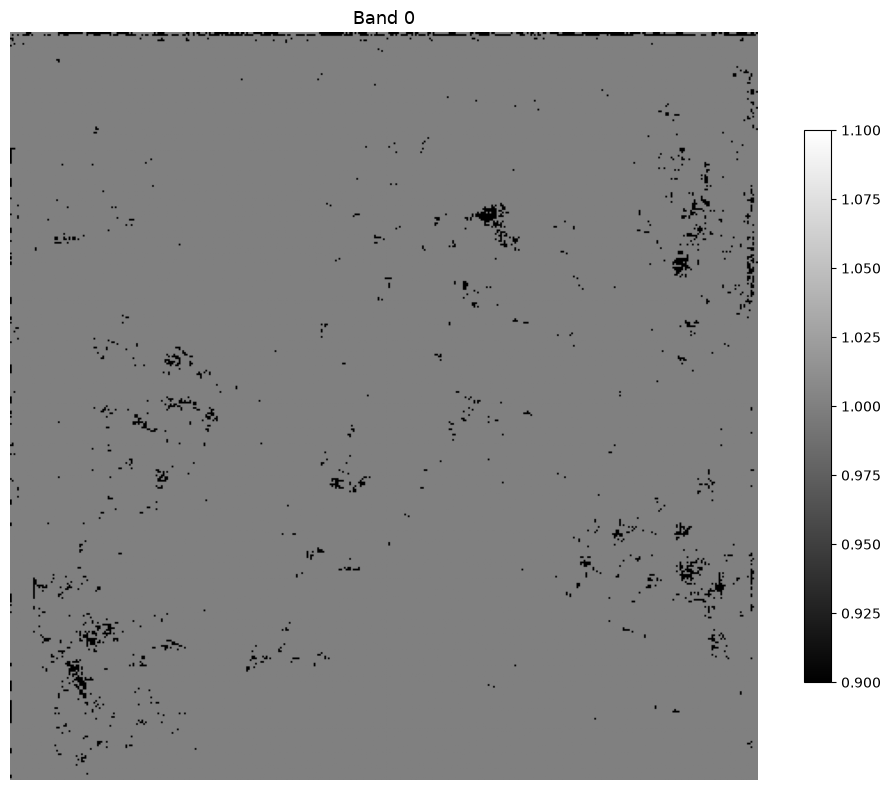

In [3]:
from pygeovision.viz import RasterViewer
from pathlib import Path

data_path = Path('/home/mrtenkorang/open-source-projects/pygeovision/docs/tutorials/pipeline_output/data/building_mask.tif')

rv = RasterViewer(data_path)
rv.single_band()

RasterViewer('stack_clipped.tif')

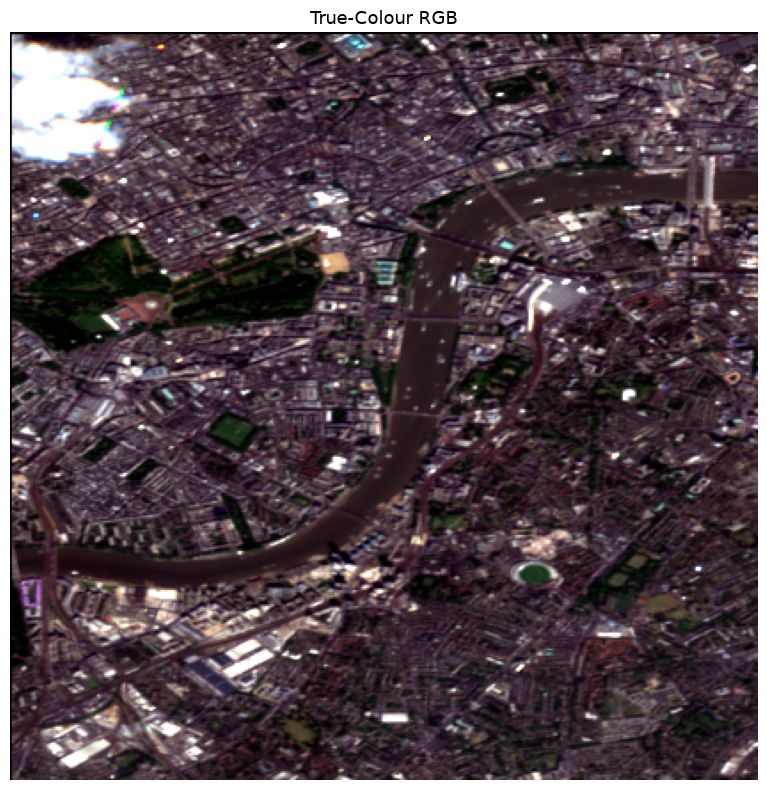

In [4]:
data_path = Path('/home/mrtenkorang/open-source-projects/pygeovision/docs/tutorials/pipeline_output/data/imagery/stack_clipped.tif')

rv = RasterViewer(data_path)
rv.rgb()

In [3]:
import pygeovision as pgv
from pygeovision.ai.pipelines import CarbonEstimationPipeline

client = pgv.PyGeoVision()

# Epping Forest — ancient woodland, high biomass for the UK
result = CarbonEstimationPipeline(client).run(
    bbox=(0.02, 51.63, 0.08, 51.68),  # Epping Forest, UK
    output_dir="./pipeline_output/data-UK/",
    date="2024-06",
    bands=("red", "green", "blue", "nir", "swir1", "swir2"),  # More bands for better carbon estimation
    providers=["planetary_computer"],
)

print("Pipeline result:")
print(f"  Status:      {'✓ Success' if result.success else '✗ Failed'}")
print(f"  Output:      {result.output_path}")
print(f"  Stats:       {result.stats}")

10:33:48 INFO [      engine] PyGeoFetch ready


2026-09-03 10:33:48,191 [INFO] pygeofetch.core.engine: PyGeoFetch ready


10:33:48 INFO [      engine] PyGeoFetch ready


2026-09-03 10:33:48,193 [INFO] pygeofetch.core.engine: PyGeoFetch ready
2026-09-03 10:33:48,193 [INFO] pygeovision.data.pgf_bridge: PyGeoFetch v1.0 Python API active — using native search/download
2026-09-03 10:33:48,194 [INFO] pygeovision.data.pgf_bridge: PyGeoFetch v2.0 processing engine detected — using native preprocessing
2026-09-03 10:33:48,199 [INFO] pygeovision.data.fetch: Searching 1 provider(s) [planetary_computer] | bbox=(0.02, 51.63, 0.08, 51.68) | 2024-06-01→2024-06-28 | cloud≤20%


┌ SEARCH PARAMETERS ───────────────────────────────────────────────────────┐
│ Providers  : planetary_computer                                          │
│ BBox       : [0.020, 51.630, 0.080, 51.680]                              │
│ Date range : 2024-06-01  →  2024-06-28                                   │
│ Cloud max  : 20.0%                                                       │
│ Product    : any                                                         │
└──────────────────────────────────────────────────────────────────────────┘
10:33:49 INFO [planetary_computer] Planetary Computer: 2 results


...

⬇ 1 scene  →  pipeline_output/data-UK/imagery  ██████████  1/1  [04:41]

  [████████████████████████████████████████] 1/1 (100%) | 404.0 MB



  ──────────────────────────────────────────────────
  ✅ Download complete: 1/1 scenes
  📦 Total size: 404.0 MB
  ⏱️  Duration: 281.7 seconds (4.7 minutes)
  ──────────────────────────────────────────────────



2026-09-03 10:38:44,253 [INFO] pygeovision.data.radiometric: stack_and_prepare_bands: masked 214204 cloud/shadow pixel(s) (0.2% of scene) using SCL
2026-09-03 10:38:44,258 [WARNING] rasterio._env: CPLE_IllegalArg in stack.tif: BLOCKXSIZE can only be used with TILED=YES
2026-09-03 10:38:58,203 [WARNING] rasterio._env: CPLE_IllegalArg in stack_clipped.tif: BLOCKXSIZE can only be used with TILED=YES
2026-09-03 10:38:58,206 [INFO] pygeovision.data.radiometric: crop_to_bbox: stack.tif ((-1.5639, 51.3245, 0.0777, 52.3414)) -> stack_clipped.tif (485x421, cropped to requested bbox)
2026-09-03 10:38:58,213 [WARNING] rasterio._env: CPLE_IllegalArg in carbon_map.tif: BLOCKXSIZE can only be used with TILED=YES


Pipeline result:
  Status:      ✓ Success
  Output:      pipeline_output/data-UK/carbon_map.tif
  Stats:       {'mean_carbon_mg_ha': 7.045709133148193, 'total_area_ha': 2227.3, 'total_carbon_mg': 15692.8}


In [ ]:
# Real BuildingFootprintsPipeline class directly -- client.pipeline() is
# PyGeoFetch's data-processing chain builder, not an AI pipeline runner;
# an earlier version of this cell misused it as if it were one.

import pygeovision as pgv
from pygeovision.ai.pipelines import BuildingFootprintsPipeline,CarbonEstimationPipeline,WaterBodiesPipeline


client = pgv.PyGeoVision()

result = BuildingFootprintsPipeline(client).run(
    bbox=(-0.15, 51.47, -0.10, 51.52),
    output_dir="./pipeline_output/data/",
    date="2024-06",
    bands=("red", "green", "blue"),
    providers=["planetary_computer",]
)

print("Pipeline result:")
print(f"  Status:      {'✓ Success' if result.success else '✗ Failed'}")
print(f"  Output:      {result.output_path}")
print(f"  Stats:       {result.stats}")
# print(f"  Duration:    {result.duration_seconds:.1f}s")

In [1]:
import pygeovision as pgv
from pygeovision.ai.pipelines import CarbonEstimationPipeline

client = pgv.PyGeoVision()

# Atewa Forest Reserve, Ghana
result = CarbonEstimationPipeline(client).run(
    bbox=(-0.65, 6.15, -0.45, 6.35),
    output_dir="./pipeline_output/data-ghana/",
    date="2026-01",
    bands=("red", "nir"),
    providers=["planetary_computer"],
)

print("Pipeline result:")
print(f"  Status:      {'✓ Success' if result.success else '✗ Failed'}")
print(f"  Output:      {result.output_path}")
print(f"  Stats:       {result.stats}")

11:02:32 INFO [      engine] PyGeoFetch ready


2026-09-03 11:02:32,113 [INFO] pygeofetch.core.engine: PyGeoFetch ready


11:02:32 INFO [      engine] PyGeoFetch ready


2026-09-03 11:02:32,116 [INFO] pygeofetch.core.engine: PyGeoFetch ready
2026-09-03 11:02:32,117 [INFO] pygeovision.data.pgf_bridge: PyGeoFetch v1.0 Python API active — using native search/download
2026-09-03 11:02:32,118 [INFO] pygeovision.data.pgf_bridge: PyGeoFetch v2.0 processing engine detected — using native preprocessing
2026-09-03 11:02:32,121 [INFO] pygeovision.data.fetch: Downloading 1 pystac-fallback item(s) directly (bypassing PyGeoFetch engine).
2026-09-03 11:02:33,704 [INFO] pygeovision.data.fetch:   [direct] S2B_MSIL2A_20260125T102219_R065_T30NYN_20260125T155454  B01 → S2B_MSIL2A_20260125T102219_R065_T30NYN_20260125T155454_B01.tif
2026-09-03 11:02:37,884 [INFO] pygeovision.data.fetch:   [direct] S2B_MSIL2A_20260125T102219_R065_T30NYN_20260125T155454  B02 → S2B_MSIL2A_20260125T102219_R065_T30NYN_20260125T155454_B02.tif
2026-09-03 11:04:57,540 [INFO] pygeovision.data.fetch:   [direct] S2B_MSIL2A_20260125T102219_R065_T30NYN_20260125T155454  B03 → S2B_MSIL2A_20260125T102219_R

Pipeline result:
  Status:      ✓ Success
  Output:      pipeline_output/data-ghana/carbon_map.tif
  Stats:       {'mean_carbon_mg_ha': 0.09847396612167358, 'total_area_ha': 27706.6, 'total_carbon_mg': 2728.4}


## Available End-to-End Pipelines

In [ ]:
# List all real, registered pipelines (51, all individually verified
# this audit cycle -- not 26, an earlier version's stale count). Real
# usage is via the CLI or the real pipeline classes directly --
# client.pipeline() is PyGeoFetch's data-processing chain builder, not
# an AI pipeline runner.
from pygeovision.ai.pipelines.domains import list_pipelines

pipes = list_pipelines()
print(f"Available pipelines ({len(pipes)}):")
for p in pipes:
    print(f"  pygeovision channel {p} --bbox ... --date ...")